# Linear Regression with PyTorch  
## A one-hour physics-first notebook

<div style="padding: 1rem; border-radius: 14px; background: linear-gradient(90deg, #eef6ff, #f8f2ff); border: 1px solid #d8e6ff;">
<b>Story for today:</b> we have a simple physics experiment. A spring is used as a force sensor. We stretch it, measure the force, and ask a neural-network style question:
<br><br>
<center><b>Can a machine learn the physical law from noisy experimental data?</b></center>
</div>

The model will be the simplest possible neural network:

$$
\hat y = wx + b.
$$

By the end, students should be able to connect:

- experimental data $\rightarrow$ tensors,
- physical model $\rightarrow$ linear layer,
- least squares $\rightarrow$ mean squared error,
- numerical optimization $\rightarrow$ gradient descent,
- PyTorch implementation $\rightarrow$ `nn.Linear`.

**Suggested timing:** 10 min data + model, 15 min loss/closed form, 20 min gradient descent, 15 min PyTorch implementation.


## 0. Setup

This notebook only needs PyTorch, NumPy, Matplotlib, Plotly, and Jupyter.

If you are running the notebook locally, install the dependencies before starting Jupyter. You can use either pip:

```bash
pip install torch numpy matplotlib plotly jupyter
```

or the provided Conda environment:

```bash
conda env create -f environment.yml
conda activate mlpytorch
```

If you are running on Google Colab or Kaggle, the next cell checks whether the required packages are already installed and installs only the missing ones. On a local machine, it skips automatic installation.


In [70]:
# Optional dependency check for hosted notebook environments.
# Local Jupyter runs skip automatic package installation.
import importlib.util
import os
import subprocess
import sys

AUTO_INSTALL_IN_HOSTED_NOTEBOOKS = True

def module_is_available(module_name):
    try:
        return importlib.util.find_spec(module_name) is not None
    except ModuleNotFoundError:
        return False

IN_COLAB = module_is_available("google.colab")
IN_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ or "KAGGLE_URL_BASE" in os.environ

required_packages = {
    "torch": "torch",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "plotly": "plotly",
}

if AUTO_INSTALL_IN_HOSTED_NOTEBOOKS and (IN_COLAB or IN_KAGGLE):
    missing_packages = [
        pip_name
        for module_name, pip_name in required_packages.items()
        if not module_is_available(module_name)
    ]

    if missing_packages:
        print("Installing missing packages:", ", ".join(missing_packages))
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
    else:
        print("All required packages are already installed.")
else:
    print("Local environment detected; skipping automatic pip installs.")


Local environment detected; skipping automatic pip installs.


### Import libraries and set defaults

This cell loads the Python libraries used throughout the notebook, sets random seeds so the generated data and training results are reproducible, configures a simple plotting style for the figures, and prints the installed PyTorch version.


In [71]:
%matplotlib inline

import math
import random
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Reproducibility
SEED = 5
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# A light plotting style for classroom use
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
})

print(f"PyTorch version: {torch.__version__}")


PyTorch version: 2.5.1


## 1. Physics example: calibrating a spring force sensor

Hooke's law says that the force is approximately proportional to the extension:

$$
F = kx.
$$

Real lab measurements are not perfect. A sensor may also have an offset, and the measurement will be influenced by experimental noise, so we use

$$
F = kx + b + \epsilon,
$$

where:

- $x$ is the spring extension in **m**,
- $F$ is the measured force in **N**,
- $k$ is the spring constant in **N/m**,
- $b$ is a small sensor offset in **N**,
- $\epsilon$ is experimental noise in **N**.



### Generate synthetic spring data

We choose a spring constant of $k = 42\,\mathrm{N/m}$, which is a realistic order of magnitude for a classroom spring. The offset $b = 0.15\,\mathrm{N}$ represents a small sensor bias, and we assume Gaussian noise with standard deviation $\sigma = 0.22\,\mathrm{N}$ represents experimental measurement error.

The dataset has $n = 60$ measurements. The spring is extended from $0.005\,\mathrm{m}$ to $0.120\,\mathrm{m}$ relative to its relaxed length.

In PyTorch, input data is usually stored as a two-dimensional tensor with shape `(number_of_samples, number_of_features)`. Here we have 60 measurements and one feature, the extension $x$, so we reshape the data to `(60, 1)`. The expression `.reshape(-1, 1)` means: keep one column, and let PyTorch infer the number of rows.

The term `noise_sigma * torch.randn(n, 1)` adds Gaussian measurement noise. `torch.randn` has mean 0 and standard deviation 1, so multiplying by `noise_sigma` gives noise with standard deviation $\sigma = 0.22\,\mathrm{N}$.


In [72]:
# True experimental law, hidden from the learner
true_k = 42.0       # N/m
true_b = 0.15       # N
noise_sigma = 0.22  # N
n = 60

# Extension in meters
x = torch.linspace(0.005, 0.120, n).reshape(-1, 1)
y = true_k * x + true_b + noise_sigma * torch.randn(n, 1)

print("x shape:", tuple(x.shape))
print("y shape:", tuple(y.shape))
print(f"True spring constant k = {true_k:.2f} N/m")
print(f"True offset b = {true_b:.3f} N")


x shape: (60, 1)
y shape: (60, 1)
True spring constant k = 42.00 N/m
True offset b = 0.150 N


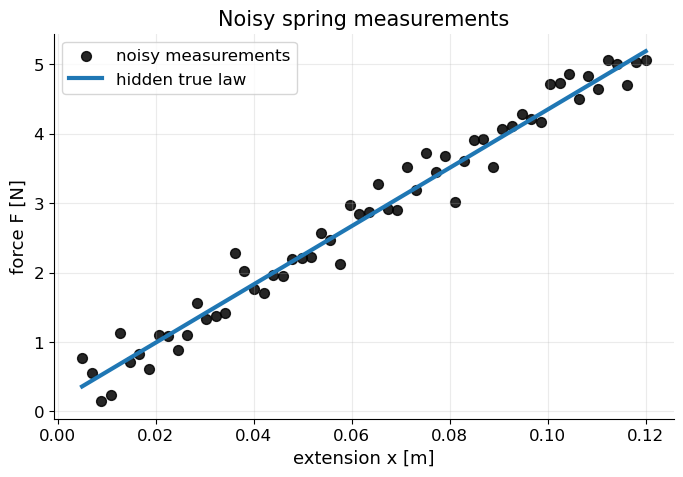

In [73]:
fig, ax = plt.subplots()
ax.scatter(x, y, s=50, color="black", alpha=0.85, label="noisy measurements")
ax.plot(x, true_k*x + true_b, linewidth=3, label="hidden true law")
ax.set_title("Noisy spring measurements")
ax.set_xlabel("extension x [m]")
ax.set_ylabel("force F [N]")
ax.legend()
plt.show()


## 2. The linear regression model

We want to learn a function from data:

$$
x_i \longmapsto y_i.
$$

For one input variable, the model is

$$
\hat y_i = wx_i + b,
$$

where $i=1,\ldots,n$. In vector notation for all data points:

$$
\hat{\mathbf y} = \mathbf{x}w + b\mathbf{1},
$$

where $\mathbf{x}$ is an $(n,1)$ column vector and $\mathbf{1}$ is a column vector of ones. 

For a fit in $d$ dimensions, the model for each data point with features $x_{i1}, x_{i2}, \ldots, x_{id}$ is

$$
\hat y_i = \mathbf{x}_i^\top \mathbf{w} + b,
$$

where a vector of weights $w_1, w_2, \ldots, w_d$ is required.

For $n$ data points in $d$ dimensions, we can write the compact form

$$
\hat{\mathbf y} = \mathbf X \mathbf w + b\mathbf{1},
$$

where $\mathbf X$ is an $(n,d)$ matrix.

As will become clear later, this is in fact a tiny neural network: one linear layer with no activation function.


### Compare a few linear fits chosen by hand

Before training anything, we can try several choices of slope $w$ and intercept $b$ by hand. Each choice gives a different line

$$
\hat y = wx + b.
$$

The mean squared error (MSE) measures how far the model predictions are from the measurements:

$$
\mathrm{MSE} = \frac{1}{n}\sum_{i=1}^n (\hat y_i - y_i)^2.
$$

A smaller MSE means the line fits the data better.


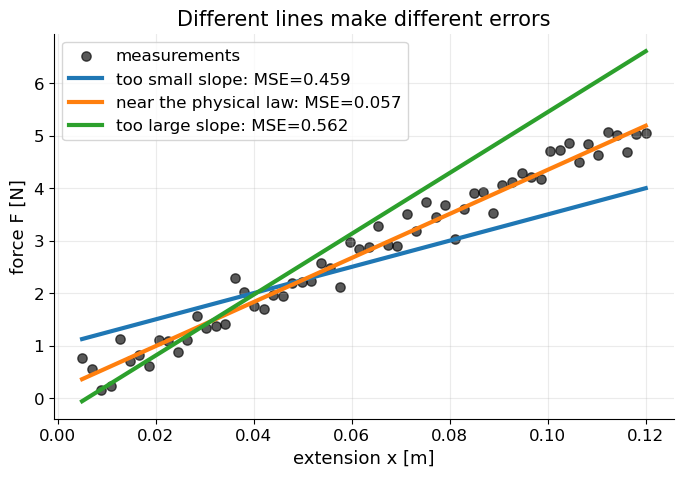

In [74]:
def model_prediction(x, w, b):
    return w * x + b            

# Three candidate models with different parameters w, b, and their descriptions
candidate_models = [
    (25.0, 1.0, "too small slope"),
    (42.0, 0.15, "near the physical law"),
    (58.0, -0.35, "too large slope"),
]

fig, ax = plt.subplots()
ax.scatter(x, y, s=45, color="black", alpha=0.65, label="measurements")

for w, b, name in candidate_models:
    y_hat = model_prediction(x, w, b)
    mse = torch.mean((y_hat - y)**2).item()
    ax.plot(x, y_hat, linewidth=3, label=f"{name}: MSE={mse:.3f}")

ax.set_title("Different lines make different errors")
ax.set_xlabel("extension x [m]")
ax.set_ylabel("force F [N]")
ax.legend()
plt.show()


## 3. Loss function: how good or bad is a model?

For each measurement at $x_i$ we define the **residual** between the prediction of the model $\hat y_i$ and the actual value $y_i$.

$$
r_i = \hat y_i - y_i.
$$

For linear regression, the standard choice for the **loss** $L(w,b)$, which is a measure of the total error of the model, is the **mean squared error** $\mathrm{MSE}$.

Why square the residuals?

1. positive and negative errors do not cancel,
2. large errors are punished more strongly,
3. the function is smooth and easy to differentiate.


### Visualize residuals

In the following plot, we construct a model by hand and show each residual as the vertical distance between the prediction of the model and the actual measurement. The MSE is the average of the squared residuals, so large vertical errors contribute strongly to the loss. The code draws one residual segment for every measurement.


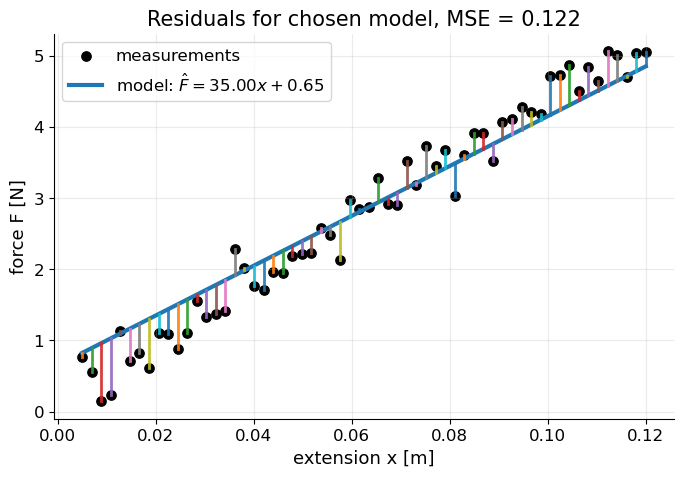

In [75]:
# Pick one candidate model and show its residuals
w_demo, b_demo = 35.0, 0.65
y_demo = model_prediction(x, w_demo, b_demo)

fig, ax = plt.subplots()
ax.scatter(x, y, s=45, color="black", label="measurements")
ax.plot(x, y_demo, linewidth=3, label=fr"model: $\hat F={w_demo:.2f}x+{b_demo:.2f}$")

# Draw one residual segment for every measurement
for xi, yi, yhi in zip(x, y, y_demo):
    ax.plot([xi.item(), xi.item()], [yi.item(), yhi.item()], linewidth=2, alpha=0.9)

mse_demo = torch.mean((y_demo - y)**2).item()
ax.set_title(f"Residuals for chosen model, MSE = {mse_demo:.3f}")
ax.set_xlabel("extension x [m]")
ax.set_ylabel("force F [N]")
ax.legend()
plt.show()


## 4. Classical least squares solution

Because the model is linear in its parameters, there is a classical numerical linear algebra solution.

Introduce the design matrix $\tilde{\mathbf X}$ with a column of ones and the parameter vector $\boldsymbol{\theta}$:

$$
\tilde{\mathbf X}=
\begin{bmatrix}
x_1 & 1\\
x_2 & 1\\
\vdots & \vdots\\
x_n & 1
\end{bmatrix},
\qquad
\boldsymbol{\theta}=
\begin{bmatrix}w\\b\end{bmatrix}.
$$

Then the vector of predictions is

$$
\hat{\mathbf y}=\tilde{\mathbf X}\boldsymbol{\theta}.
$$

The least-squares problem is calculating the optimal parameters $\boldsymbol{\theta}^*$ that minimize the sum of squares of all residuals.

$$
\boldsymbol{\theta}^* = \arg\min_{\boldsymbol{\theta}}
\left\|\hat{\mathbf y}-\mathbf y\right\|_2^2,
$$
where  $\|\mathbf{r}\|_2=\sqrt{r_1^2+r_2^2+\cdots+r_n^2}$ is the 2-norm. 

When $\tilde{\mathbf X}^{\top}\tilde{\mathbf X}$ is invertible, a closed-form solution to this problem is obtained as
$$
\boldsymbol{\theta}^*=\left(\tilde{\mathbf{X}}^{\top} \tilde{\mathbf{X}}\right)^{-1} \tilde{\mathbf{X}}^{\top} \mathbf{y}
$$

In PyTorch, we can use `torch.linalg.lstsq` to calculate the optimal parameters $\boldsymbol{\theta}^*$.


Least-squares slope       w = 42.4771 N/m
Least-squares intercept   b = 0.1395 N


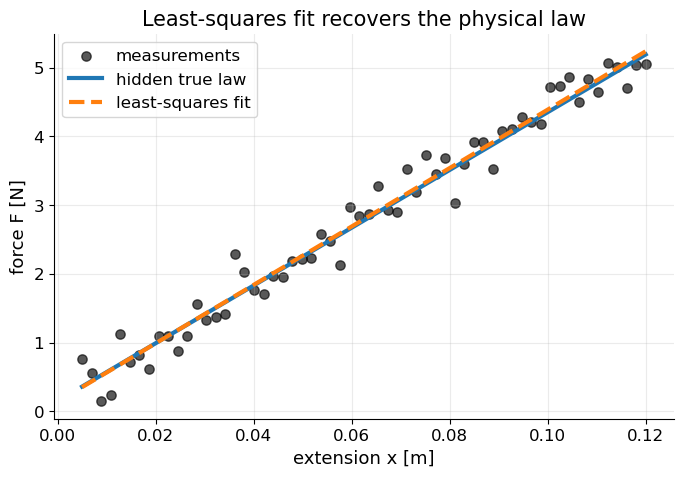

In [76]:
X_design = torch.cat([x, torch.ones_like(x)], dim=1)  # [x, 1]
solution = torch.linalg.lstsq(X_design, y).solution
w_lstsq, b_lstsq = solution[0, 0], solution[1, 0]

print(f"Least-squares slope       w = {w_lstsq.item():.4f} N/m")
print(f"Least-squares intercept   b = {b_lstsq.item():.4f} N")

fig, ax = plt.subplots()
ax.scatter(x, y, s=45, color="black", alpha=0.65, label="measurements")
ax.plot(x, true_k*x + true_b, linewidth=3, label="hidden true law")
ax.plot(x, model_prediction(x, w_lstsq, b_lstsq), "--", linewidth=3, label="least-squares fit")
ax.set_title("Least-squares fit recovers the physical law")
ax.set_xlabel("extension x [m]")
ax.set_ylabel("force F [N]")
ax.legend()
plt.show()


## 5. Same problem, neural-network style: gradient descent

Deep learning usually does not solve a closed-form linear algebra problem. It **minimizes a loss iteratively**.

For linear regression,

$$
L(w,b)=\frac{1}{n}\sum_{i=1}^n(wx_i+b-y_i)^2.
$$

The gradients are

$$
\frac{\partial L}{\partial w}
=\frac{2}{n}\sum_{i=1}^n x_i(wx_i+b-y_i),
$$

$$
\frac{\partial L}{\partial b}
=\frac{2}{n}\sum_{i=1}^n(wx_i+b-y_i).
$$

**Gradient descent** updates the parameters by

$$
w \leftarrow w - \eta\frac{\partial L}{\partial w},
\qquad
b \leftarrow b - \eta\frac{\partial L}{\partial b},
$$

where $\eta$ is the learning rate.


### Check gradients with autograd

Gradient descent needs the derivatives of the loss with respect to the trainable parameters $w$ and $b$:

$$
\frac{\partial L}{\partial w},
\qquad
\frac{\partial L}{\partial b}.
$$

PyTorch can compute these derivatives automatically. Setting `requires_grad=True` tells PyTorch to track operations involving `w` and `b`. After computing the loss, `loss.backward()` applies backpropagation and stores the derivatives in `w.grad` and `b.grad`.

For this simple model, we can also compute the gradients by hand. The cell below compares the manual formulas with PyTorch autograd at one arbitrary parameter choice.


In [77]:
# Compare manual gradients with PyTorch autograd at one arbitrary point
w = torch.tensor(0.10, requires_grad=True)
b = torch.tensor(1.00, requires_grad=True)

loss = torch.mean((model_prediction(x, w, b) - y)**2)
loss.backward()

with torch.no_grad():
    residuals = model_prediction(x, w, b) - y
    manual_dw = 2 * torch.mean(x * residuals)
    manual_db = 2 * torch.mean(residuals)

print(f"Autograd dL/dw = {w.grad.item(): .6f} | manual dL/dw = {manual_dw.item(): .6f}")
print(f"Autograd dL/db = {b.grad.item(): .6f} | manual dL/db = {manual_db.item(): .6f}")


Autograd dL/dw = -0.320078 | manual dL/dw = -0.320078
Autograd dL/db = -3.576093 | manual dL/db = -3.576093


### Train with full-batch gradient descent

Now we let the computer improve the parameters instead of choosing them by hand. Full-batch gradient descent uses the entire dataset to compute one loss value and one pair of gradients at each epoch.

The function starts from initial guesses `w0` and `b0`. At every epoch it:

1. computes predictions,
2. computes the MSE loss,
3. calls `loss.backward()` to compute gradients,
4. updates $w$ and $b$ in the downhill direction,
5. resets the gradients before the next epoch.

The learning rate `lr` controls the step size. The list `path` stores the values of $w$, $b$, and the loss during training so that we can plot the optimization path later.

The update is wrapped in `torch.no_grad()` because the parameter update itself should not become part of the computation graph.


In [78]:
def train_full_batch_gd(x, y, lr=0.8, epochs=2000, w0=-5.0, b0=1.80):
    w = torch.tensor(float(w0), requires_grad=True)
    b = torch.tensor(float(b0), requires_grad=True)
    path = []

    for epoch in range(epochs):
        y_hat = model_prediction(x, w, b)
        loss = torch.mean((y_hat - y)**2)
        loss.backward()

        with torch.no_grad():
            path.append((w.item(), b.item(), loss.item()))
            w -= lr * w.grad
            b -= lr * b.grad
            w.grad.zero_()
            b.grad.zero_()

    return w.detach(), b.detach(), np.array(path)

w_gd, b_gd, path = train_full_batch_gd(x, y)

print(f"Gradient descent slope       w = {w_gd.item():.4f} N/m")
print(f"Gradient descent intercept   b = {b_gd.item():.4f} N")
print(f"Estimated spring constant    k = {w_gd.item():.2f} N/m")
print(f"Final MSE                    L = {path[-1, 2]:.5f}")


Gradient descent slope       w = 41.2270 N/m
Gradient descent intercept   b = 0.2177 N
Estimated spring constant    k = 41.23 N/m
Final MSE                    L = 0.05865


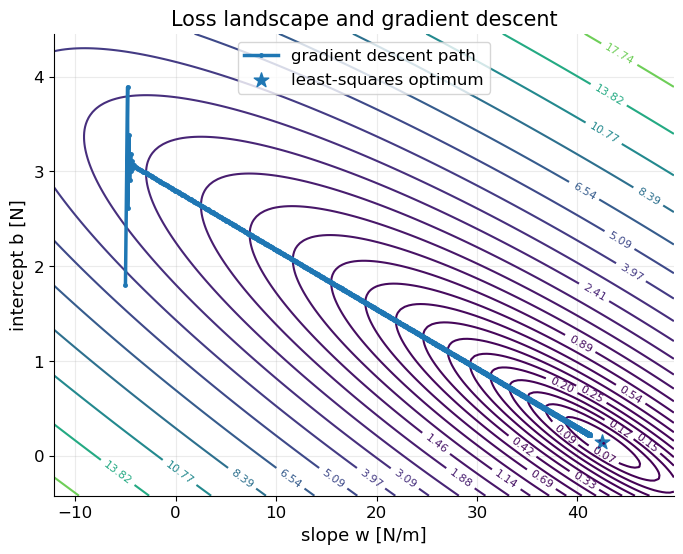

In [79]:
# Plot the loss surface and the path followed by gradient descent
w_plot_values = np.concatenate([path[:, 0], [w_lstsq.item()]])
b_plot_values = np.concatenate([path[:, 1], [b_lstsq.item()]])

w_padding = max(0.15 * (w_plot_values.max() - w_plot_values.min()), 5.0)
b_padding = max(0.15 * (b_plot_values.max() - b_plot_values.min()), 0.50)

w_values = torch.linspace(float(w_plot_values.min() - w_padding), float(w_plot_values.max() + w_padding), 160)
b_values = torch.linspace(float(b_plot_values.min() - b_padding), float(b_plot_values.max() + b_padding), 160)
W, B = torch.meshgrid(w_values, b_values, indexing="xy")

# Broadcast to compute the MSE at every point of the grid
Y_hat_grid = W[..., None] * x.flatten() + B[..., None]
Loss_grid = torch.mean((Y_hat_grid - y.flatten())**2, dim=-1)

fig, ax = plt.subplots(figsize=(8, 6))
levels = np.geomspace(Loss_grid.min().item() + 1e-4, Loss_grid.max().item(), 25)
cs = ax.contour(W.numpy(), B.numpy(), Loss_grid.numpy(), levels=levels)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

ax.plot(path[:, 0], path[:, 1], marker="o", markersize=2.5, linewidth=2.5, label="gradient descent path")
ax.scatter([w_lstsq.item()], [b_lstsq.item()], s=120, marker="*", label="least-squares optimum")
ax.set_title("Loss landscape and gradient descent")
ax.set_xlabel("slope w [N/m]")
ax.set_ylabel("intercept b [N]")
ax.legend()
plt.show()


### Loss landscape as a surface

The contour plot shows level curves of the loss. The same information can be viewed as a three-dimensional surface, where the horizontal axes are the parameters $w$ and $b$, and the vertical axis is the MSE loss. The bottom of the surface is the best-fitting line.


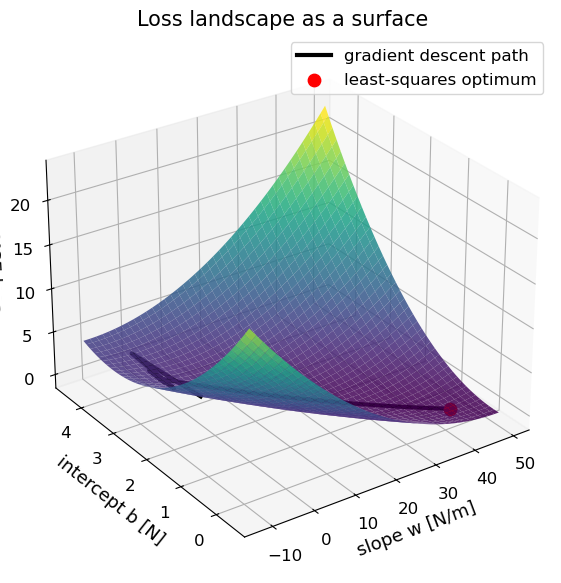

In [80]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    W.numpy(),
    B.numpy(),
    Loss_grid.numpy(),
    cmap="viridis",
    alpha=0.85,
    linewidth=0,
    antialiased=True,
)

ax.plot(
    path[:, 0],
    path[:, 1],
    path[:, 2],
    color="black",
    linewidth=3,
    label="gradient descent path",
)

loss_lstsq = torch.mean((model_prediction(x, w_lstsq, b_lstsq) - y)**2).item()
ax.scatter(
    [w_lstsq.item()],
    [b_lstsq.item()],
    [loss_lstsq],
    color="red",
    s=80,
    label="least-squares optimum",
)

ax.set_title("Loss landscape as a surface")
ax.set_xlabel("slope w [N/m]")
ax.set_ylabel("intercept b [N]")
ax.set_zlabel("MSE loss")
ax.view_init(elev=28, azim=-125)
ax.legend()
plt.show()


### Interactive loss landscape

The Matplotlib surface above is static in most notebook settings. Plotly creates an interactive version that can be rotated, zoomed, and inspected directly in the notebook.


In [81]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Surface(
        x=W.numpy(),
        y=B.numpy(),
        z=Loss_grid.numpy(),
        colorscale="Viridis",
        opacity=0.85,
        name="MSE loss",
        showscale=True,
    )
)

fig.add_trace(
    go.Scatter3d(
        x=path[:, 0],
        y=path[:, 1],
        z=path[:, 2],
        mode="lines",
        line=dict(color="black", width=6),
        name="gradient descent path",
    )
)

fig.add_trace(
    go.Scatter3d(
        x=[w_lstsq.item()],
        y=[b_lstsq.item()],
        z=[loss_lstsq],
        mode="markers",
        marker=dict(color="red", size=6),
        name="least-squares optimum",
    )
)

fig.update_layout(
    title="Interactive loss landscape",
    scene=dict(
        xaxis_title="slope w [N/m]",
        yaxis_title="intercept b [N]",
        zaxis_title="MSE loss",
    ),
    width=850,
    height=650,
)

fig.show()


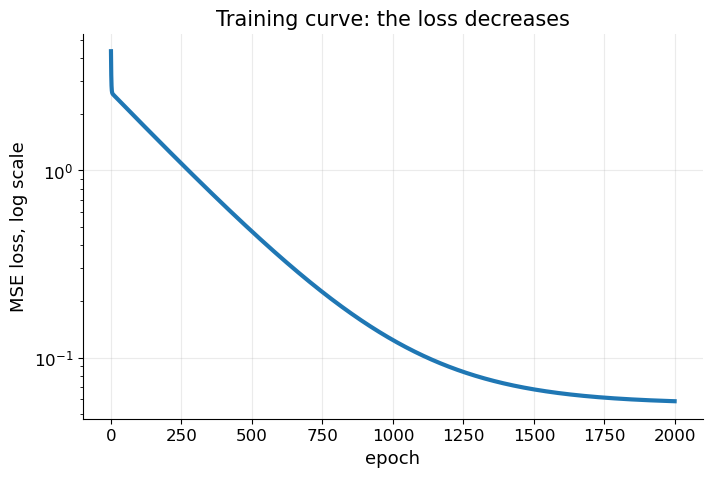

In [82]:
fig, ax = plt.subplots()
ax.plot(path[:, 2], linewidth=3)
ax.set_yscale("log")
ax.set_title("Training curve: the loss decreases")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss, log scale")
plt.show()


## 6. Why feature scaling matters

Physics students know this from numerical analysis: scaling can change the conditioning of a problem.

Here, $x$ is measured in m and ranges roughly from $0.005$ to $0.120$. A common machine-learning preprocessing step is to standardize the input:

$$
z = \frac{x-\mu_x}{\sigma_x}.
$$

We train the model

$$
\hat y = w_z z + b_z.
$$

To convert back to physical units,

$$
\hat y = w_z\frac{x-\mu_x}{\sigma_x}+b_z
= \left(\frac{w_z}{\sigma_x}\right)x + \left(b_z - \frac{w_z\mu_x}{\sigma_x}\right).
$$

So the physical slope and intercept are

$$
w = \frac{w_z}{\sigma_x},
\qquad
b = b_z - \frac{w_z\mu_x}{\sigma_x}.
$$


In [83]:
x_mean = x.mean()
x_std = x.std()
z = (x - x_mean) / x_std

print(f"mean(x) = {x_mean.item():.4f} m")
print(f"std(x)  = {x_std.item():.4f} m")
print(f"mean(z) = {z.mean().item():.3f}")
print(f"std(z)  = {z.std().item():.3f}")


mean(x) = 0.0625 m
std(x)  = 0.0340 m
mean(z) = 0.000
std(z)  = 1.000


## 7. Linear regression from scratch with mini-batches

The basic training loop has five steps:

1. take a mini-batch of data,
2. compute predictions,
3. compute loss,
4. compute gradients with `loss.backward()`,
5. update parameters.

This is the same skeleton used later for MLPs and CNNs.


In [84]:
def data_iter(batch_size, features, labels):
    n = len(features)
    indices = torch.randperm(n)
    for i in range(0, n, batch_size):
        batch_indices = indices[i:i+batch_size]
        yield features[batch_indices], labels[batch_indices]

# Parameters in standardized coordinates: y_hat = w_z z + b_z
w_z = torch.normal(0, 0.01, size=(1, 1), requires_grad=True)
b_z = torch.zeros(1, requires_grad=True)

lr = 0.05
batch_size = 10
num_epochs = 30
loss_history = []

for epoch in range(num_epochs):
    for X_batch, y_batch in data_iter(batch_size, z, y):
        y_hat = X_batch @ w_z + b_z
        loss = torch.mean((y_hat - y_batch)**2)
        loss.backward()

        with torch.no_grad():
            w_z -= lr * w_z.grad
            b_z -= lr * b_z.grad
            w_z.grad.zero_()
            b_z.grad.zero_()

    with torch.no_grad():
        epoch_loss = torch.mean((z @ w_z + b_z - y)**2).item()
        loss_history.append(epoch_loss)

# Convert trained parameters back to physical units
w_physical = w_z.item() / x_std.item()
b_physical = b_z.item() - w_z.item() * x_mean.item() / x_std.item()

print(f"Learned w_z, b_z in standardized coordinates: {w_z.item():.4f}, {b_z.item():.4f}")
print(f"Converted slope       w = {w_physical:.4f} N/m")
print(f"Converted intercept   b = {b_physical:.4f} N")
print(f"Estimated spring constant k = {w_physical:.2f} N/m")


Learned w_z, b_z in standardized coordinates: 1.4437, 2.8009
Converted slope       w = 42.4106 N/m
Converted intercept   b = 0.1502 N
Estimated spring constant k = 42.41 N/m


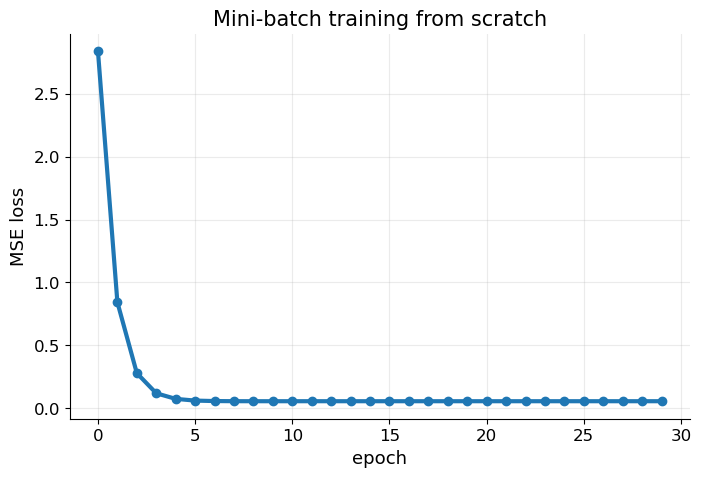

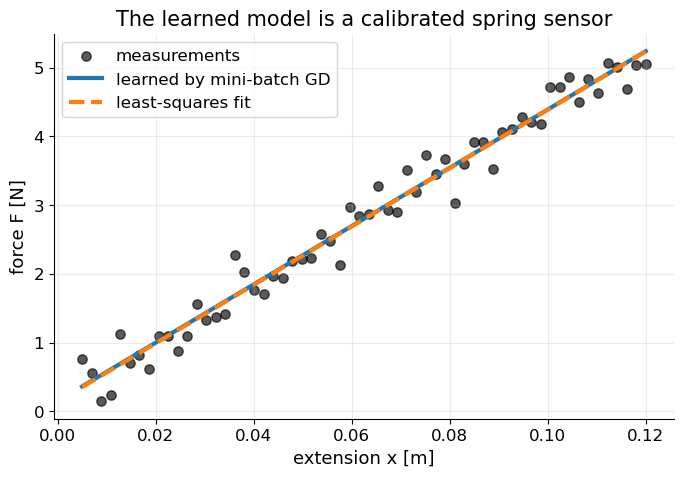

In [85]:
fig, ax = plt.subplots()
ax.plot(loss_history, marker="o", linewidth=3)
ax.set_title("Mini-batch training from scratch")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss")
plt.show()

fig, ax = plt.subplots()
ax.scatter(x, y, s=45, color="black", alpha=0.65, label="measurements")
ax.plot(x, model_prediction(x, w_physical, b_physical), linewidth=3, label="learned by mini-batch GD")
ax.plot(x, model_prediction(x, w_lstsq, b_lstsq), "--", linewidth=3, label="least-squares fit")
ax.set_title("The learned model is a calibrated spring sensor")
ax.set_xlabel("extension x [m]")
ax.set_ylabel("force F [N]")
ax.legend()
plt.show()


## 8. The concise PyTorch implementation

Now we write the same model using PyTorch building blocks:

- `TensorDataset` stores input-output pairs,
- `DataLoader` creates shuffled mini-batches,
- `nn.Linear(1, 1)` represents

$$
\hat y = wz + b,
$$

- `nn.MSELoss()` computes the mean squared error,
- `torch.optim.SGD` performs gradient descent.

This is the version students should recognize as the template for later neural networks.


In [86]:
dataset = TensorDataset(z, y)
loader = DataLoader(dataset, batch_size=10, shuffle=True)

model = nn.Linear(in_features=1, out_features=1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

loss_history_pytorch = []

for epoch in range(30):
    for X_batch, y_batch in loader:
        y_hat = model(X_batch)
        loss = loss_fn(y_hat, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        epoch_loss = loss_fn(model(z), y).item()
        loss_history_pytorch.append(epoch_loss)

w_z_nn = model.weight.item()
b_z_nn = model.bias.item()
w_nn = w_z_nn / x_std.item()
b_nn = b_z_nn - w_z_nn * x_mean.item() / x_std.item()

print("PyTorch nn.Linear parameters")
print(f"standardized coordinates: w_z = {w_z_nn:.4f}, b_z = {b_z_nn:.4f}")
print(f"physical coordinates:     w = {w_nn:.4f} N/m, b = {b_nn:.4f} N")
print(f"estimated spring constant: k = {w_nn:.2f} N/m")


PyTorch nn.Linear parameters
standardized coordinates: w_z = 1.4428, b_z = 2.7949
physical coordinates:     w = 42.3840 N/m, b = 0.1459 N
estimated spring constant: k = 42.38 N/m


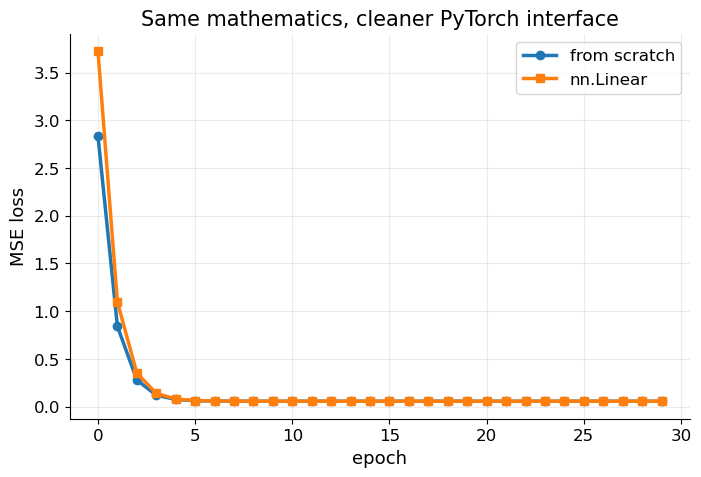

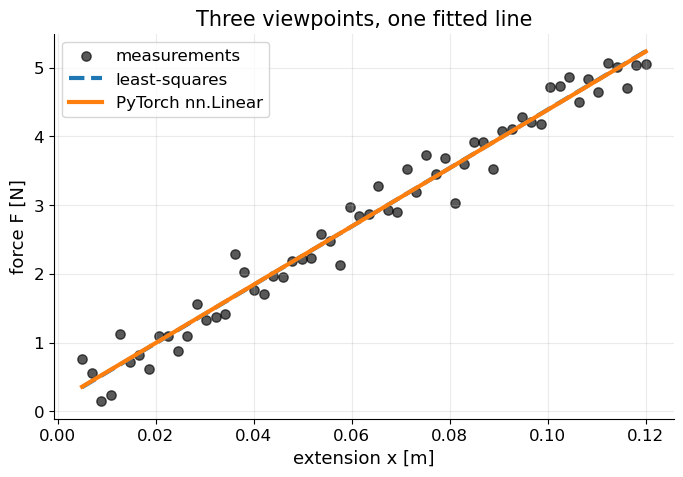

In [87]:
fig, ax = plt.subplots()
ax.plot(loss_history, marker="o", linewidth=2.5, label="from scratch")
ax.plot(loss_history_pytorch, marker="s", linewidth=2.5, label="nn.Linear")
ax.set_title("Same mathematics, cleaner PyTorch interface")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.scatter(x, y, s=45, color="black", alpha=0.65, label="measurements")
ax.plot(x, model_prediction(x, w_lstsq, b_lstsq), "--", linewidth=3, label="least-squares")
ax.plot(x, model_prediction(x, w_nn, b_nn), linewidth=3, label="PyTorch nn.Linear")
ax.set_title("Three viewpoints, one fitted line")
ax.set_xlabel("extension x [m]")
ax.set_ylabel("force F [N]")
ax.legend()
plt.show()


In [88]:
with torch.no_grad():
    y_pred_multi = model_multi(Z_multi)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_multi, y_pred_multi, color="black", alpha=0.7)
lims = [min(y_multi.min().item(), y_pred_multi.min().item()),
        max(y_multi.max().item(), y_pred_multi.max().item())]
ax.plot(lims, lims, linewidth=3, label="perfect prediction")
ax.set_title("Two-feature linear regression: predicted vs measured")
ax.set_xlabel("measured force [N]")
ax.set_ylabel("predicted force [N]")
ax.legend()
plt.show()


NameError: name 'model_multi' is not defined

## 10. What students should remember

<div style="padding: 1rem; border-radius: 14px; background: #fff8e8; border: 1px solid #f1d08a;">
Linear regression is not just a statistics method. It is also the simplest trainable neural network layer.
</div>

The core concepts are:

1. **Model**

   $$
   \hat y = \mathbf{x}^\top\mathbf{w}+b.
   $$

2. **Loss**

   $$
   L=\frac{1}{n}\sum_i(\hat y_i-y_i)^2.
   $$

3. **Optimization**

   $$
   \theta \leftarrow \theta - \eta\nabla_\theta L.
   $$

4. **PyTorch training loop**

   ```python
   optimizer.zero_grad()
   loss.backward()
   optimizer.step()
   ```

5. **Physical interpretation**

   The learned slope is not just a number. In this example it directly estimates the spring constant in N/m.


## 11. Short exercises for students

### Exercise 1 — Change the noise
Increase `noise_sigma` from `0.22` to `0.60`. What happens to the fitted line? What happens to the uncertainty you would expect in the estimated spring constant $k$?

### Exercise 2 — Bad learning rate
In the full-batch gradient descent section, try `lr=0.05`, `lr=0.8`, and `lr=1.1`. Which one is too slow? Which one is unstable?

### Exercise 3 — Feature scaling
Train once with the raw extension values in meters and once with the standardized values `z`. Which training curve is easier to optimize? Why does scaling help even though the physical model is the same?

### Exercise 4 — Mini-batch size
Try batch sizes `1`, `10`, and `60`. Compare the training curves.

### Exercise 5 — Add a useless feature
Add a random feature to `X_multi`. Does the model learn a coefficient close to zero? Why might this fail for small datasets or large noise?
